# Beschreibung des Schweißprozesses in Zusammenhang mit den Merkmalen der multivariaten Zeitreihe 

## Der Schweißprozess

In der Anlage wird das Ende eines Stahlbands mit dem Anfang des nächsten verschweißt. Dafür werden beide
Bänder leicht überlappt und von Hydraulikzylinder geklemmt. Das eigentliche Schweißwerkzeug sitzt auf einem C-Wagen, der quer über das Band fährt...

## Die multivariate Zeitreihe

Der Datensatz besteht aus **14** Parquet-Dateien (**63** Merkmale $\approx$ **1,08 Mrd.** Zeilen). Eine binäre Spalte "Schweißen EIN" kennzeichnet, ob der Schweißvorgang aktiv ist. Zusammenhängende Zeitabschnitte mit aktivem Schweißvorgang werden als einzelne Sequenzen erkannt. Insgesamt ergeben sich **383** Schweißsequenzen.

## Beispielsequenz

Für die Betrachtung wurde die 2. Schweißsequenz ausgewählt.

In [1]:
import glob, datetime as dt
import polars as pl
import matplotlib.pyplot as plt

files = sorted(glob.glob('./data/EV__*.parquet'))
lf = pl.scan_parquet(files[0]) 
EIN = '[72_1]S7-Schweißmaschine - Schweißen EIN (M215_0)'


df_aug = (
    lf.select('Time', EIN).drop_nulls()
    .with_columns(seq_id=(pl.col(EIN) & ~pl.col(EIN).shift(fill_value=False)).cum_sum() - 1)
    .filter(pl.col(EIN))
    .group_by('seq_id').agg(start=pl.col('Time').min(), end=pl.col('Time').max())
    .sort('seq_id').collect(engine='streaming')
)

SEQ = 1
s = df_aug.filter(pl.col('seq_id') == SEQ).row(0, named=True)
start_time, end_time = s['start'], s['end']

cols = [c for c in lf.collect_schema().names() if c != 'Time']

df_seq = (
    lf
    .filter(pl.col('Time').is_between(start_time, end_time))
    .select('Time', *cols)
    .with_columns(t=(pl.col('Time') - start_time).dt.total_milliseconds() / 1000)
    .collect(engine='streaming')
)


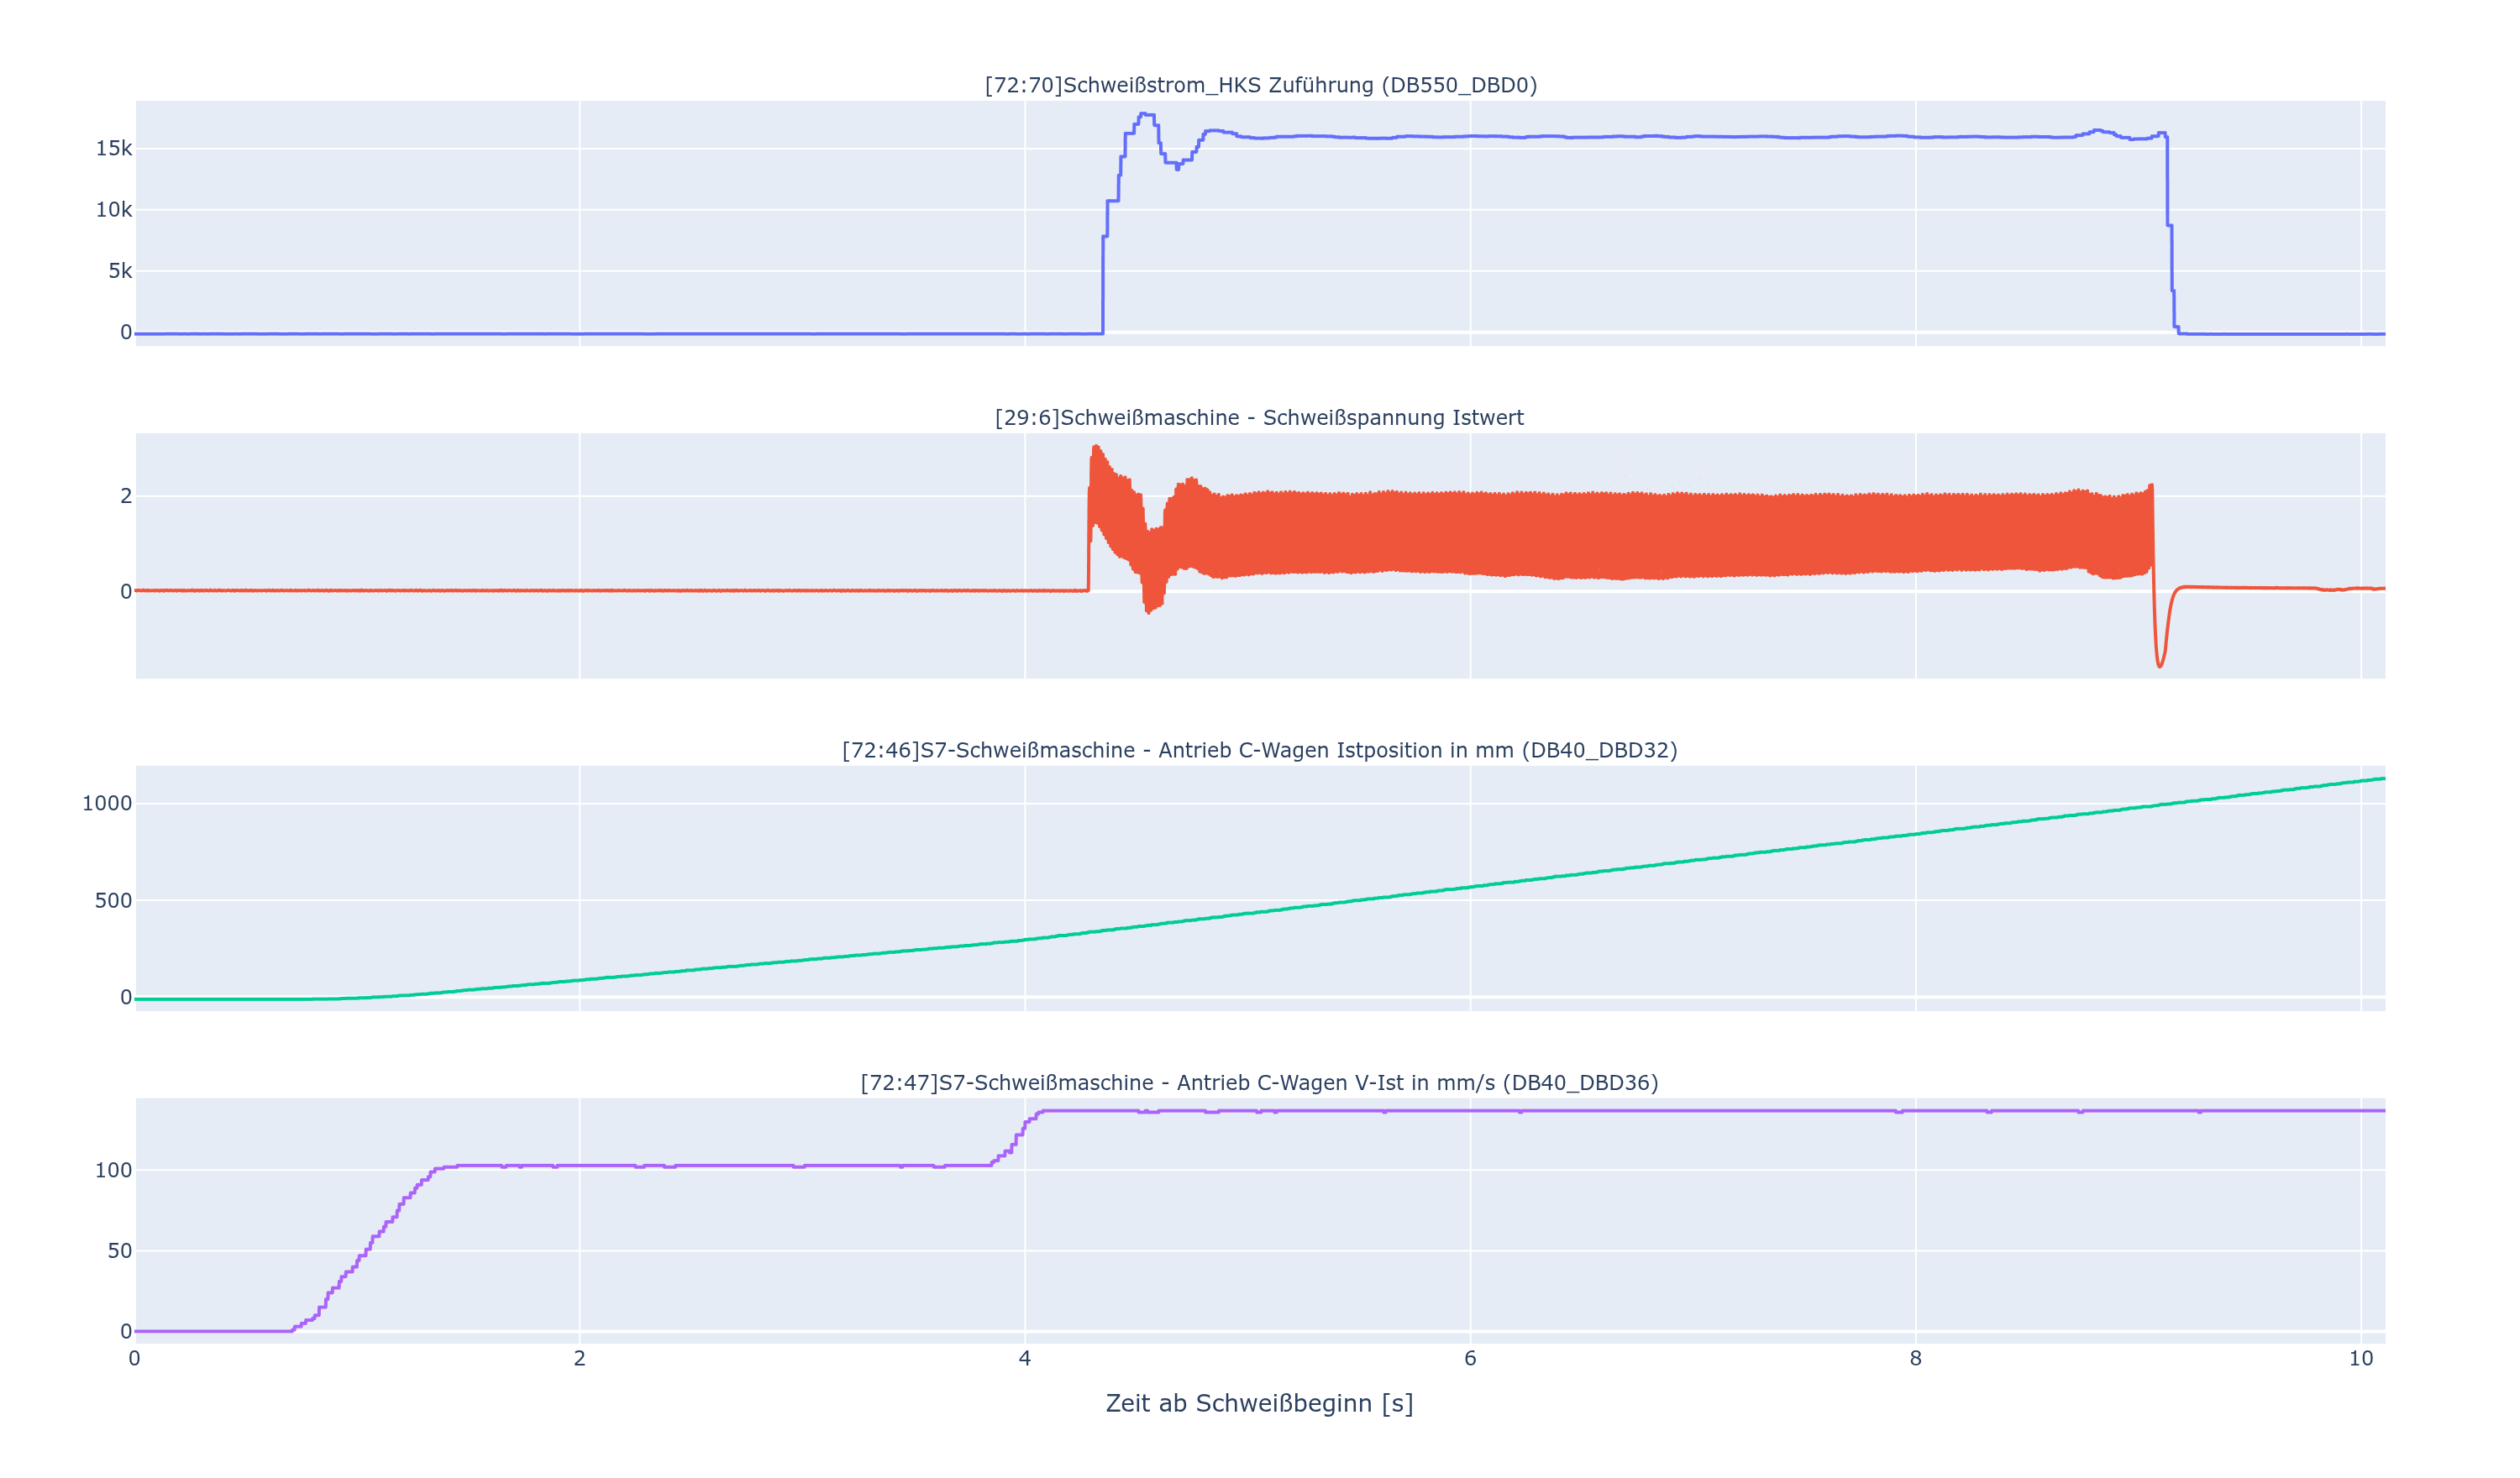

In [2]:
import plotly.express as px
from IPython.display import Image

plot_cols = [
    '[72:70]Schweißstrom_HKS Zuführung (DB550_DBD0)',
    '[29:6]Schweißmaschine - Schweißspannung Istwert',
    '[72:46]S7-Schweißmaschine - Antrieb C-Wagen Istposition in mm (DB40_DBD32)',
    '[72:47]S7-Schweißmaschine - Antrieb C-Wagen V-Ist in mm/s (DB40_DBD36)',
]

fig = px.line(df_seq.select('t', *plot_cols),
              x='t', y=plot_cols, facet_col='variable', facet_col_wrap=1,
              height=220 * len(plot_cols), render_mode='webgl')

fig.update_yaxes(matches=None, title=None)
fig.update_xaxes(title=None)
fig.update_xaxes(title='Zeit ab Schweißbeginn [s]', row=1)  # nur unterste Facette
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=', 1)[1]))
fig.update_layout(showlegend=False, hovermode='x unified')
fig.write_image(f'./Images/report_seq{SEQ + 1}.png', width=1500, scale=2)
Image(f'./Images/report_seq{SEQ + 1}.png')